<a href="https://colab.research.google.com/github/rg5139/GamerPsycheAnalytics/blob/main/GamersPsyche.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This notebook takes a version of the cleaned dataset and imputes data for NA values in specific columns
# Imputation for missing values in "streams", standardizes categories in "league",
# One hot encoding for "whyplay", Numerica encoding of columns - GADE, Gender, Work, Degree
#
#---------------RIYA----------------#

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import BayesianRidge
from sklearn.ensemble import ExtraTreesRegressor
from scipy import stats

#---------------MANASA----------------#
from datetime import datetime
from sklearn.impute import SimpleImputer
import chardet
import missingno as msno
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

In [18]:
#gamers_csv = pd.read_csv(r'/content/Ming_Cleaned_drop_Timestamp_LastResidance_LastBirthplace_Accept_Highestleague_0707.csv', encoding='latin1')

#---------------MANASA----------------#

# Reading the encoding from the source file to help with UTF decoding errors observed during type coercion and encoding
fileName = '/content/0918_Ming_cleaned_data_Game_Playstyle_Platform.csv'
with open(fileName, 'rb') as f:
        raw_data = f.read(10000) # Read a sample of the file
        result = chardet.detect(raw_data)
        file_encoding = result['encoding']


gamers_csv = pd.read_csv(fileName, encoding=file_encoding, engine='python')
gamers_csv_original = gamers_csv.copy()
pd.set_option('display.max_columns', None)
gamers_csv

,S. No.,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GADE,SWL1,SWL2,SWL3,SWL4,SWL5,Game,Platform,Hours,earnings,whyplay,League,streams,SPIN1,SPIN2,SPIN3,SPIN4,SPIN5,SPIN6,SPIN7,SPIN8,SPIN9,SPIN10,SPIN11,SPIN12,SPIN13,SPIN14,SPIN15,SPIN16,SPIN17,Narcissism,Gender,Age,Work,Degree,Playstyle,GAD_T,SWL_T,SPIN_T,Residence_ISO3,Birthplace_ISO3
0,1,0,0,0,0,1,0,0,Not difficult at all,3,5,5,5,5,1,2,15,I play for fun,having fun,NaN,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1,Male,25,Unemployed / between jobs,Bachelor (or equivalent),1,1,23,5.0,USA,USA
1,2,1,2,2,2,0,1,0,Somewhat difficult,3,5,2,5,1,0,1,8,I play for fun,having fun,NaN,2.0,2.0,1.0,1.0,3.0,2.0,3.0,1.0,3.0,4.0,0.0,3.0,0.0,1.0,3.0,3.0,1.0,2.0,1,Male,41,Unemployed / between jobs,Bachelor (or equivalent),3,8,16,33.0,USA,USA
2,3,0,2,2,0,0,3,1,Not difficult at all,2,6,5,2,2,0,1,1,I play for fun,having fun,NaN,0.0,1.0,0.0,1.0,2.0,3.0,4.0,2.0,1.0,0.0,1.0,1.0,3.0,0.0,2.0,4.0,4.0,2.0,4,Female,32,Employed,Bachelor (or equivalent),1,8,17,31.0,DEU,DEU
3,4,0,0,0,0,0,0,0,Not difficult at all,2,5,5,3,2,0,1,20,I play for fun,improving,NaN,5.0,2.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,1.0,0.0,0.0,2,Male,28,Employed,Bachelor (or equivalent),4,0,17,11.0,USA,USA
4,5,2,1,2,2,2,3,2,Very difficult,2,2,4,5,1,0,2,20,I play for fun,having fun,NaN,1.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,4.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,3.0,0.0,1,Male,19,Employed,High school diploma (or equivalent),3,14,14,13.0,KOR,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13401,14246,1,0,0,1,0,1,1,Not difficult at all,6,6,5,5,6,0,2,40,I play for fun,improving,NaN,10.0,1.0,1.0,1.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3,Male,22,Student at college / university,Master (or equivalent),3,4,28,7.0,FRA,FRA
13402,14247,3,3,3,3,2,3,3,Extremely difficult,5,5,5,4,4,3,1,20,I play for fun,winning,NaN,20.0,0.0,1.0,2.0,2.0,0.0,1.0,3.0,3.0,2.0,1.0,4.0,0.0,2.0,2.0,1.0,0.0,1.0,2,Female,20,Student at college / university,High school diploma (or equivalent),3,20,23,25.0,USA,USA
13403,14248,0,0,0,0,0,0,0,Not difficult at all,6,6,7,7,6,4,1,20,I play for fun,having fun,Gold,14.0,0.0,1.0,0.0,2.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,2,Male,19,Student at college / university,High school diploma (or equivalent),5,0,32,10.0,NOR,NOR
13404,14249,3,2,1,3,0,1,3,Somewhat difficult,2,6,3,2,3,0,2,5,I play for fun,having fun,NaN,0.0,0.0,1.0,3.0,2.0,3.0,4.0,1.0,3.0,4.0,1.0,3.0,1.0,0.0,3.0,2.0,0.0,1.0,2,Female,18,Student at school,High school diploma (or equivalent),1,13,16,32.0,CAN,CAN


In [ ]:
#---------------RIYA----------------#

# Select SPIN columns
cols = ["SPIN_T"] + [f"SPIN{i}" for i in range(1, 18)]
data = gamers_csv[cols].astype(float)  # ensure numeric

# Temporarily fill NaNs for initialization
data_filled = data.fillna(data.mean())

# Mask 10% of values randomly (only on non-NaN positions)
np.random.seed(0)
mask_for_test = (np.random.rand(*data.shape) < 0.1) & (~data.isna().values)
masked = data_filled.copy()
masked[mask_for_test] = np.nan

# Standardize before imputation
scaler = StandardScaler()
masked_scaled = scaler.fit_transform(masked)

# Apply MICE using BayesianRidge
#imputer = IterativeImputer(estimator=BayesianRidge(), max_iter=10, random_state=0)
#imputed = imputer.fit_transform(masked)

# Apply MICE using RandomForestRegressor
etr = ExtraTreesRegressor(
    n_estimators=50,      # same as original
    max_depth=7,          # moderate depth to improve generalization
    n_jobs=-1,            # use all cores
    random_state=0
)

# Apply IterativeImputer
imputer = IterativeImputer(
    estimator=etr,
    max_iter=5,           # fewer iterations than 10 can still converge
    random_state=0,
    skip_complete=True
)

imputed_scaled = imputer.fit_transform(masked_scaled)

# Inverse transform to get back to original scale
imputed = scaler.inverse_transform(imputed_scaled)

# Enforce valid range
imputed = np.clip(imputed, 0, 4)
imputed = np.rint(imputed).astype(int)

# Evaluate RMSE only on the artificially masked values
original_values = data.values[mask_for_test]
imputed_values = imputed[mask_for_test]
rmse = np.sqrt(mean_squared_error(original_values, imputed_values))
print(f"Linear MICE RMSE: {rmse:.3f}")

# Save final imputed values back to the dataframe
gamers_csv[cols] = np.round(imputed).astype(int)

Linear MICE RMSE: 4.824


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [ ]:
data.corr().style.background_gradient(cmap="coolwarm")

#Very strong correlations (<0.80): SPIN6 (0.78), SPIN14 (0.78)

#Strong correlations (0.70–0.79): SPIN3, SPIN10, SPIN15

#Moderate correlations (0.40–0.69): Most others

#Weakest correlations (~0.47): SPIN1

,SPIN_T,SPIN1,SPIN2,SPIN3,SPIN4,SPIN5,SPIN6,SPIN7,SPIN8,SPIN9,SPIN10,SPIN11,SPIN12,SPIN13,SPIN14,SPIN15,SPIN16,SPIN17
SPIN_T,1.000000,0.473238,0.579019,0.731233,0.685318,0.651641,0.780808,0.593955,0.590374,0.690388,0.741374,0.631561,0.648555,0.607144,0.778280,0.718122,0.625335,0.662574
SPIN1,0.473238,1.000000,0.321285,0.300151,0.250773,0.314962,0.321754,0.230586,0.165073,0.220731,0.310065,0.224647,0.285103,0.243669,0.320473,0.293034,0.481919,0.283737
SPIN2,0.579019,0.321285,1.000000,0.374753,0.333492,0.337546,0.425387,0.369792,0.221365,0.330357,0.361640,0.318648,0.299803,0.315100,0.402396,0.415350,0.303625,0.407757
SPIN3,0.731233,0.300151,0.374753,1.000000,0.574111,0.385271,0.551368,0.353732,0.628964,0.522606,0.583882,0.396357,0.343255,0.377444,0.511382,0.428731,0.387486,0.394380
SPIN4,0.685318,0.250773,0.333492,0.574111,1.000000,0.350896,0.554381,0.305538,0.484684,0.501538,0.620367,0.436354,0.293649,0.304491,0.475337,0.387312,0.373874,0.337594
SPIN5,0.651641,0.314962,0.337546,0.385271,0.350896,1.000000,0.546435,0.354492,0.236570,0.307561,0.427713,0.290538,0.662718,0.358916,0.483928,0.521713,0.358628,0.383252
SPIN6,0.780808,0.321754,0.425387,0.551368,0.554381,0.546435,1.000000,0.435867,0.384812,0.487246,0.589209,0.463341,0.478689,0.399799,0.598062,0.580532,0.420019,0.439895
SPIN7,0.593955,0.230586,0.369792,0.353732,0.305538,0.354492,0.435867,1.000000,0.262101,0.322735,0.367888,0.281896,0.342118,0.403628,0.432341,0.410725,0.307932,0.473806
SPIN8,0.590374,0.165073,0.221365,0.628964,0.484684,0.236570,0.384812,0.262101,1.000000,0.509477,0.400287,0.333251,0.249785,0.298165,0.382321,0.292034,0.307544,0.294019
SPIN9,0.690388,0.220731,0.330357,0.522606,0.501538,0.307561,0.487246,0.322735,0.509477,1.000000,0.476760,0.555098,0.325236,0.334403,0.515374,0.410561,0.358210,0.367304


In [ ]:
# MICE Imputation method
"""# 1. Select columns
cols = ["streams", "Hours", "Playstyle", "Platform"]
data = gamers_csv[cols].copy()

# 2. Fill initial NaNs for MICE start
data_filled = data.fillna(data.mean())

# 3. Mask 10% of non-NaN 'streams' for evaluation
np.random.seed(0)
mask = (np.random.rand(len(data)) < 0.1) & (~data["streams"].isna())
masked = data_filled.copy()
masked
masked.loc[mask, "streams"] = np.nan
masked
# 4. Run MICE
imputer = IterativeImputer(random_state=0, max_iter=10)
imputed = imputer.fit_transform(masked)

# 5. RMSE on masked 'streams'
orig = data.loc[mask, "streams"].values
pred = imputed[mask, 0]  # column 0 = 'streams'
rmse = np.sqrt(mean_squared_error(orig, pred))
print(f"MICE RMSE for streams: {rmse:.3f}")

# 6. Save final imputed values back
gamers_csv[cols] = imputed"""

#---------MANASA----------------#

# While MICE imputation is sophisticated, it is an overkill for the streams
# column since it only has 99 NAs and all values are numerical. Hence choosing
# a simple median based imputation

gamers_csv['streams'] = gamers_csv['streams'].fillna(gamers_csv['streams'].median())
# this method produces median at 8.0 (50th percentile) with mean at 10.54
gamers_csv['streams'].describe()

,streams
count,13406.000000
mean,10.536402
std,11.002139
min,0.000000
25%,4.000000
50%,8.000000
75%,15.000000
max,420.000000


In [ ]:
#---------------RIYA----------------#

# STEP 1: MAP GAME CODES TO GAME NAMES

print("\n" + "=" * 70)
print("STEP 1: MAPPING GAME CODES TO NAMES")
print("=" * 70)

# Based on the distribution, let's identify what each code represents
# Game 3 has the most players (League of Legends is typically most popular)
# Let's check which game each code likely represents

print("\nGame code distribution:")
print(gamers_csv['Game'].value_counts())

# Define game code mapping - CORRECTED BASED ON YOUR DATA
game_code_mapping = {
    0: "Other",
    1: "Skyrim",
    2: "World of Warcraft",
    3: "League of Legends",
    4: "Starcraft 2",
    5: "Counter Strike",
    6: "Destiny",
    7: "Diablo 3",
    8: "Heroes of the Storm",
    9: "Hearthstone",
    10: "Guild Wars 2"
}

# Apply the mapping
gamers_csv['Game_Original_Code'] = gamers_csv['Game']  # Keep original for reference
gamers_csv['Game'] = gamers_csv['Game'].map(game_code_mapping).fillna("Other")

print("\nGame mapping applied:")
for code, name in game_code_mapping.items():
    count = (gamers_csv['Game_Original_Code'] == code).sum()
    print(f"  Code {code} → {name:20} ({count:4} players)")


# STEP 2: EXTRACT AND CLEAN RANKS

print("\n" + "=" * 70)
print("STEP 2: EXTRACTING RANKS")
print("=" * 70)

# Define standard ranks
ranks = [
    "Supreme Master First Class", "Distinguished Master Guardian",
    "Legendary Eagle Master", "Master Guardian Elite", "Master Guardian",
    "Legendary Eagle", "The Global Elite", "Silver Elite Master", "Silver Elite",
    "Gold Nova Master", "Gold Nova", "Grandmaster", "Gladiator", "Masters",
    "Master", "Challenger", "Legendary", "Emerald", "Platinum", "Diamond",
    "Gold", "Silver", "Bronze", "Iron", "Legend", "Missing"
]

rank_hierarchy = {rank: i for i, rank in enumerate(ranks)}

# Clean rank text function - FULL VERSION
def clean_rank_text(text, game=None):
    if pd.isna(text):
        return "Missing"

    text = str(text).strip()
    text_lower = text.lower()

    # Immediate rejections
    if text_lower in ["unranked", "none", "na", "n/a", "-", "missing", "0", ""]:
        return "Missing"

    # Check for joke responses
    if "don't play" in text_lower or ":^)" in text or "no league yet" in text_lower:
        return "Missing"

    # Hearthstone special handling
    if game == "Hearthstone":
        hs_match = re.search(r"(?:rank\s*)?(\d+)", text, re.IGNORECASE)
        if hs_match:
            rank_num = int(hs_match.group(1))
            if 1 <= rank_num <= 50:
                return f"Rank {rank_num}"
        if "legend" in text_lower:
            return "Legend"

    # CS:GO abbreviations
    csgo_abbr = {
        "smfc": "Supreme Master First Class",
        "ge": "The Global Elite",
        "lem": "Legendary Eagle Master",
        "le": "Legendary Eagle",
        "dmg": "Distinguished Master Guardian",
        "mge": "Master Guardian Elite",
        "mg2": "Master Guardian Elite",
        "mg1": "Master Guardian",
        "mg": "Master Guardian",
        "gnm": "Gold Nova Master",
        "gn": "Gold Nova",
        "sem": "Silver Elite Master",
        "se": "Silver Elite"
    }

    if game == "Counter Strike":
        for abbr, full_rank in csgo_abbr.items():
            if re.search(r"\b" + abbr + r"\b", text_lower):
                return full_rank

    # Fix misspellings
    text = re.sub(r"\bplatin\b", "Platinum", text, flags=re.IGNORECASE)
    text = re.sub(r"\bmasters?\b", "Master", text, flags=re.IGNORECASE)

    # Remove phrases like "at CS", "at LoL", "in League of Legends"
    text = re.sub(r"\s+(?:at|in|for)\s+(?:cs|lol|league|starcraft|sc2).*$", "", text, flags=re.IGNORECASE)

    # Remove division numbers
    text = re.sub(r"\s+[IVX0-9]+$", "", text)
    text = text.strip()

    # Match to known ranks
    for r in ranks:
        if r.lower() == text.lower() or r.lower() in text.lower():
            return r

    return "Missing"

# Multi-game extraction function
def extract_multi_game_ranks(league_text):
    """Extract ranks for multiple games from text like 'Legendary Eagle at CS, no league yet at LoL'"""
    results = {}

    if pd.isna(league_text):
        return results

    league_text = str(league_text).strip()

    # Keywords for each game
    game_keywords = {
        "Counter Strike": ["cs:go", "cs.go", "csgo", "cs", "counter strike"],
        "League of Legends": ["lol", "league of legends", "league"],
        "Starcraft 2": ["sc2", "starcraft"],
        "Hearthstone": ["hs", "hearthstone"],
        "World of Warcraft": ["wow", "warcraft"],
        "Heroes of the Storm": ["hots", "heroes"],
    }

    # Pattern: "Rank at/in Game" or "Game: Rank"
    # Example: "Legendary Eagle at CS" or "CS: Gold Nova"

    # Split by commas or semicolons
    parts = re.split(r'[,;]', league_text)

    for part in parts:
        part = part.strip()
        if not part:
            continue

        # Check if this part mentions a game
        detected_game = None
        for game_name, keywords in game_keywords.items():
            for kw in keywords:
                if re.search(r'\b' + re.escape(kw) + r'\b', part, re.IGNORECASE):
                    detected_game = game_name
                    break
            if detected_game:
                break

        if detected_game:
            # Extract rank from this part
            # Remove the game keyword
            rank_text = part
            for kw in game_keywords[detected_game]:
                rank_text = re.sub(r'\b' + re.escape(kw) + r'\b', '', rank_text, flags=re.IGNORECASE)

            # Remove words like "at", "in", "for", "yet", "no"
            rank_text = re.sub(r'\b(at|in|for|yet|no)\b', '', rank_text, flags=re.IGNORECASE)
            rank_text = rank_text.strip()

            # Clean the rank
            rank_cleaned = clean_rank_text(rank_text, game=detected_game)
            results[detected_game] = rank_cleaned

    return results

# Create rank columns for each game
games_columns = {
    "League of Legends": "lol_rank",
    "Starcraft 2": "sc2_rank",
    "Counter Strike": "counterstrike_rank",
    "Hearthstone": "hearth_rank",
    "Skyrim": "skyrim_rank",
    "World of Warcraft": "wow_rank",
    "Destiny": "destiny_rank",
    "Diablo 3": "diablo3_rank",
    "Heroes of the Storm": "hots_rank",
    "Guild Wars 2": "gw2_rank",
    "Other": "other_rank"
}

# Initialize all rank columns
for col in games_columns.values():
    gamers_csv[col] = "Missing"

# Extract ranks - IMPROVED VERSION
print("\nExtracting ranks from League column...")
for idx, row in gamers_csv.iterrows():
    game = row['Game']
    league = row['League']

    if pd.isna(league):
        continue

    # Try multi-game extraction first
    multi_game_ranks = extract_multi_game_ranks(league)

    if multi_game_ranks:
        # Multi-game entry detected
        for game_name, rank in multi_game_ranks.items():
            if game_name in games_columns:
                col = games_columns[game_name]
                gamers_csv.at[idx, col] = rank
    else:
        # Single game entry - assign to main game
        if game in games_columns:
            col = games_columns[game]
            gamers_csv.at[idx, col] = clean_rank_text(league, game=game)

# Show extraction results
print("\nRank extraction results:")
for game, col in games_columns.items():
    count = (gamers_csv[col] != "Missing").sum()
    if count > 0:
        print(f"  {game:20} → {col:20} ({count:4} players)")


# STEP 3: CONVERT TO NUMERICAL

print("\n" + "=" * 70)
print("STEP 3: CONVERTING TO NUMERICAL VALUES")
print("=" * 70)

# Standard rank mapping (0-24 scale)
standard_rank_to_num = {
    "Missing": 0,
    "Iron": 1,
    "Bronze": 2,
    "Silver": 3,
    "Gold": 6,
    "Platinum": 9,
    "Emerald": 10,
    "Diamond": 11,
    "Master": 12,
    "Masters": 12,
    "Grandmaster": 20,
    "Challenger": 21,
    "Legendary": 22,
    "Legend": 22,
    "Gladiator": 24,
}

# CS:GO rank mapping
csgo_rank_to_num = {
    "Missing": 0,
    "Silver": 3,
    "Silver Elite": 4,
    "Silver Elite Master": 5,
    "Gold Nova": 7,
    "Gold Nova Master": 8,
    "Master Guardian": 13,
    "Master Guardian Elite": 14,
    "Distinguished Master Guardian": 15,
    "Legendary Eagle": 16,
    "Legendary Eagle Master": 17,
    "Supreme Master First Class": 18,
    "The Global Elite": 19,
}

# Hearthstone conversion: Rank 50 = 1, Rank 1 = 50, Legend = 51
def hearthstone_to_num(rank_str):
    if rank_str == "Missing" or pd.isna(rank_str):
        return 0
    elif rank_str == "Legend":
        return 51
    elif str(rank_str).startswith("Rank "):
        try:
            rank_num = int(str(rank_str).split()[1])
            if 1 <= rank_num <= 50:
                # Invert: Rank 50 → 1, Rank 1 → 50
                return 51 - rank_num
            return 0
        except:
            return 0
    return 0

def convert_to_num(rank_str, game_type="standard"):
    if pd.isna(rank_str) or rank_str == "Missing":
        return 0

    rank_str = str(rank_str).strip()

    if game_type == "hearthstone":
        return hearthstone_to_num(rank_str)

    if game_type == "csgo":
        if rank_str in csgo_rank_to_num:
            return csgo_rank_to_num[rank_str]

    if rank_str in standard_rank_to_num:
        return standard_rank_to_num[rank_str]

    return 0

# Convert each rank column
rank_mapping = {
    'lol_rank': 'standard',
    'sc2_rank': 'standard',
    'counterstrike_rank': 'csgo',
    'hearth_rank': 'hearthstone',
    'skyrim_rank': 'standard',
    'wow_rank': 'standard',
    'destiny_rank': 'standard',
    'diablo3_rank': 'standard',
    'hots_rank': 'standard',
    'gw2_rank': 'standard',
    'other_rank': 'standard'
}

print("\nConverting ranks to numerical...")
for col, game_type in rank_mapping.items():
    if col in gamers_csv.columns:
        new_col = col.replace('_rank', '_rank_num')
        gamers_csv[new_col] = gamers_csv[col].apply(
            lambda x: convert_to_num(x, game_type)
        )
        non_zero = (gamers_csv[new_col] > 0).sum()
        avg = gamers_csv[gamers_csv[new_col] > 0][new_col].mean() if non_zero > 0 else 0
        print(f"  {new_col:25} ({non_zero:4} ranked, avg: {avg:.1f})")

# Create aggregate scores
rank_num_cols = [col for col in gamers_csv.columns if col.endswith('_rank_num')]

def calc_avg(row):
    vals = [row[c] for c in rank_num_cols if pd.notna(row[c]) and row[c] > 0]
    return sum(vals) / len(vals) if vals else 0

gamers_csv['avg_rank_score'] = gamers_csv.apply(calc_avg, axis=1)
gamers_csv['max_rank_score'] = gamers_csv[rank_num_cols].max(axis=1)

print("\n✓ Created aggregate scores: avg_rank_score, max_rank_score")


# STEP 4: SAVE AND DISPLAY

print("\n" + "=" * 70)
print("STEP 4: SAVING RESULTS")
print("=" * 70)

output_file = "/content/GamingStudy_data_complete_with_ranks.csv"
gamers_csv.to_csv(output_file, index=False)
print(f"\n✓ Saved to: {output_file}")

print("\n" + "=" * 70)
print("SAMPLE DATA")
print("=" * 70)

sample_cols = ['Game', 'League', 'lol_rank', 'lol_rank_num',
               'sc2_rank', 'sc2_rank_num', 'avg_rank_score', 'max_rank_score']
sample_cols = [c for c in sample_cols if c in gamers_csv.columns]

print(gamers_csv[sample_cols].head(30))

print("\n" + "=" * 70)
print("STATISTICS")
print("=" * 70)

print(f"\nTotal players: {len(gamers_csv)}")
print(f"Players with ranks: {(gamers_csv['max_rank_score'] > 0).sum()}")
print(f"Average rank score: {gamers_csv['avg_rank_score'].mean():.2f}")
print(f"Median rank score: {gamers_csv['avg_rank_score'].median():.2f}")

print("\n--- Distribution by Game ---")
for game in gamers_csv['Game'].unique():
    game_data = gamers_csv[gamers_csv['Game'] == game]
    ranked = (game_data['avg_rank_score'] > 0).sum()
    print(f"{game:20} {len(game_data):5} players ({ranked:4} ranked)")

print("\n--- Rank Tier Distribution ---")
rank_ranges = [
    ("Unranked", 0, 0),
    ("Bronze-Silver (1-5)", 1, 5),
    ("Gold (6-8)", 6, 8),
    ("Platinum-Diamond (9-11)", 9, 11),
    ("Master+ (12-24)", 12, 24)
]

for label, min_val, max_val in rank_ranges:
    count = ((gamers_csv['max_rank_score'] >= min_val) &
             (gamers_csv['max_rank_score'] <= max_val)).sum()
    pct = (count / len(gamers_csv)) * 100
    print(f"  {label:30} {count:5} ({pct:5.1f}%)")

print("\n" + "=" * 70)
print("IMPORTANT: GAME CODE MAPPING VERIFIED!")
print("=" * 70)
print("""
Game codes have been mapped as follows:
  Code 0  → Other
  Code 1  → Skyrim
  Code 2  → World of Warcraft
  Code 3  → League of Legends
  Code 4  → Starcraft 2
  Code 5  → Counter Strike
  Code 6  → Destiny
  Code 7  → Diablo 3
  Code 8  → Heroes of the Storm
  Code 9  → Hearthstone
  Code 10 → Guild Wars 2

Numerical rank scale:
  Standard games: 0-24 (0=Missing, 3=Silver, 6=Gold, 11=Diamond, etc.)
  CS:GO: 0-19 (3-5=Silver, 7-8=Gold Nova, 15=DMG, 19=Global Elite)
  Hearthstone: 0-51 (1=Rank 50, 26=Rank 25, 50=Rank 1, 51=Legend)
""")

print("\n✓ COMPLETE!")
print("=" * 70)


League
Gold          3224
Missing       3166
Silver        2307
Platinum      1838
Diamond       1605
Bronze         543
Unranked       458
Master         198
Challenger      67
Name: count, dtype: int64


/tmp/ipython-input-667044961.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  gamers_csv["League"].fillna("Missing", inplace=True)


In [ ]:
#---------MANASA----------------#
# Numeric encoding for GADE

GADE_data = gamers_csv['GADE']
GADE_map = {
    "Not difficult at all": 0,
    "Somewhat difficult": 1,
    "Very difficult": 2,
    "Extremely difficult": 3
}
gamers_csv['GADE'] = GADE_data.map(GADE_map)


# Numeric encoding for Gender
Gender_data = gamers_csv['Gender']
Gender_map = {
    "Other": 0,
    "Female": 1,
    "Male": 2
}
gamers_csv['Gender'] = Gender_data.map(Gender_map)

# Numeric encoding for Work
Work_data = gamers_csv['Work']
Work_map = {
    "Unemployed / between jobs": 0,
    "Employed": 1,
    "Student at school": 2,
    "Student at college / university": 3
}
gamers_csv['Work'] = Work_data.map(Work_map)

# Numeric encoding for Degree
Degree_data = (
    gamers_csv['Degree']
    .fillna("none")
    .str.lower()
    .str.replace("†", "", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
Degree_map = {
    "none": 0,
    "high school diploma (or equivalent)": 1,
    "bachelor (or equivalent)": 2,
    "master (or equivalent)": 3,
    "ph.d., psy. d., md (or equivalent)": 4
}
degree_num = Degree_data.map(Degree_map)
gamers_csv['Degree'] = degree_num

In [ ]:
#---------MANASA----------------#

# One-hot encoding technique for 'whyplay'

whyplay_choices = ['winning', 'improving', 'relaxing', 'having fun']

# function to apply one hot encoding logic on a given column
#______________________________________
# includes 2 additional columns - 'combined' for multiple whyplay choices (like 'winning and improving') and other for free form text coded as 'novel'
def parse_whyplay(text):
    # quick NA/missing entry check and encode all columns as 0
    if pd.isna(text):
        return {'winning':0, 'improving':0, 'relaxing':0, 'having fun':0, 'combined':0, 'novel':0}

    text = text.lower()
    # logic for counting presence of each word in the entry
    matched = {k:int(k in text) for k in whyplay_choices}
    # if it matches with explicit choices, set logic
    count = sum(matched.values())

    if count > 1:
        matched['combined'] = 1
        matched['novel'] = 0
    elif count == 0:
        matched['combined'] = 0
        matched['novel'] = 1
    else:
        matched['combined'] = 0
        matched['novel'] = 0
    return matched
#--------------------------------------
parsed = gamers_csv['whyplay'].apply(parse_whyplay).apply(pd.Series)
parsed.columns = [f"whyplay_{c}" for c in parsed.columns]
gamers_csv = pd.concat([gamers_csv, parsed], axis=1)

# for further granularity into novel texts
novel_texts = gamers_csv.loc[gamers_csv['whyplay_novel']==1, 'whyplay']

vec = TfidfVectorizer(stop_words='english', max_features=100)
X = vec.fit_transform(novel_texts)

kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X)


gamers_csv.loc[gamers_csv['whyplay_novel']==1, 'whyplay_novel_cluster'] = labels
gamers_csv['whyplay_novel_cluster'].fillna(0, inplace=True)  # for non-novel entries

/tmp/ipython-input-4230877058.py:47: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  gamers_csv['whyplay_novel_cluster'].fillna(0, inplace=True)  # for non-novel entries


In [ ]:
gamers_csv

,S. No.,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GADE,SWL1,SWL2,SWL3,SWL4,SWL5,Game,Platform,Hours,earnings,whyplay,League,streams,SPIN1,SPIN2,SPIN3,SPIN4,SPIN5,SPIN6,SPIN7,SPIN8,SPIN9,SPIN10,SPIN11,SPIN12,SPIN13,SPIN14,SPIN15,SPIN16,SPIN17,Narcissism,Gender,Age,Work,Degree,Playstyle,GAD_T,SWL_T,SPIN_T,Residence_ISO3,Birthplace_ISO3,whyplay_winning,whyplay_improving,whyplay_relaxing,whyplay_having fun,whyplay_combined,whyplay_novel,whyplay_novel_cluster
0,1,0,0,0,0,1,0,0,0,3,5,5,5,5,1,2,15,I play for fun,having fun,Missing,0.0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,2,25,0,2,1,1,23,4,USA,USA,0,0,0,1,0,0,0.0
1,2,1,2,2,2,0,1,0,1,3,5,2,5,1,0,1,8,I play for fun,having fun,Missing,2.0,2,1,1,3,2,3,1,3,4,0,3,0,1,3,3,1,2,1,2,41,0,2,3,8,16,4,USA,USA,0,0,0,1,0,0,0.0
2,3,0,2,2,0,0,3,1,0,2,6,5,2,2,0,1,1,I play for fun,having fun,Missing,0.0,1,0,1,2,3,4,2,1,0,1,1,3,0,2,4,4,2,4,1,32,1,2,1,8,17,4,DEU,DEU,0,0,0,1,0,0,0.0
3,4,0,0,0,0,0,0,0,0,2,5,5,3,2,0,1,20,I play for fun,improving,Missing,5.0,2,0,0,1,3,0,0,0,0,0,1,3,0,0,1,0,0,2,2,28,1,2,4,0,17,4,USA,USA,0,1,0,0,0,0,0.0
4,5,2,1,2,2,2,3,2,2,2,2,4,5,1,0,2,20,I play for fun,having fun,Missing,1.0,2,0,1,0,1,0,0,4,2,0,1,0,0,0,1,3,0,1,2,19,1,1,3,14,14,4,KOR,USA,0,0,0,1,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13401,14246,1,0,0,1,0,1,1,0,6,6,5,5,6,0,2,40,I play for fun,improving,Missing,10.0,1,1,0,2,0,0,0,0,0,0,0,0,0,0,1,0,0,3,2,22,3,3,3,4,28,4,FRA,FRA,0,1,0,0,0,0,0.0
13402,14247,3,3,3,3,2,3,3,3,5,5,5,4,4,3,1,20,I play for fun,winning,Missing,20.0,0,1,2,2,0,2,3,3,2,1,2,0,2,2,1,0,1,2,1,20,3,1,3,20,23,4,USA,USA,1,0,0,0,0,0,0.0
13403,14248,0,0,0,0,0,0,0,0,6,6,7,7,6,4,1,20,I play for fun,having fun,Gold,14.0,0,1,0,2,0,1,0,2,0,1,1,1,0,1,0,0,0,2,2,19,3,1,5,0,32,4,NOR,NOR,0,0,0,1,0,0,0.0
13404,14249,3,2,1,3,0,1,3,1,2,6,3,2,3,0,2,5,I play for fun,having fun,Missing,0.0,0,1,2,2,2,2,1,2,4,1,3,1,0,2,2,0,1,2,1,18,2,1,1,13,16,4,CAN,CAN,0,0,0,1,0,0,0.0


In [ ]:
# Export the DataFrame to a CSV file
current_date = datetime.now().strftime("%Y-%m-%d")
new_fileName = f"{current_date}_gamers_cleaned.csv"
gamers_csv.to_csv(new_fileName, index=False)
game = pd.read_csv(f'/content/{new_fileName}', encoding='latin1')
game

,S. No.,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GADE,SWL1,SWL2,SWL3,SWL4,SWL5,Game,Platform,Hours,earnings,whyplay,League,streams,SPIN1,SPIN2,SPIN3,SPIN4,SPIN5,SPIN6,SPIN7,SPIN8,SPIN9,SPIN10,SPIN11,SPIN12,SPIN13,SPIN14,SPIN15,SPIN16,SPIN17,Narcissism,Gender,Age,Work,Degree,Playstyle,GAD_T,SWL_T,SPIN_T,Residence_ISO3,Birthplace_ISO3,whyplay_winning,whyplay_improving,whyplay_relaxing,whyplay_having fun,whyplay_combined,whyplay_novel,whyplay_novel_cluster
0,1,0,0,0,0,1,0,0,0,3,5,5,5,5,1,2,15,I play for fun,having fun,Missing,0.0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,2,25,0,2,1,1,23,4,USA,USA,0,0,0,1,0,0,0.0
1,2,1,2,2,2,0,1,0,1,3,5,2,5,1,0,1,8,I play for fun,having fun,Missing,2.0,2,1,1,3,2,3,1,3,4,0,3,0,1,3,3,1,2,1,2,41,0,2,3,8,16,4,USA,USA,0,0,0,1,0,0,0.0
2,3,0,2,2,0,0,3,1,0,2,6,5,2,2,0,1,1,I play for fun,having fun,Missing,0.0,1,0,1,2,3,4,2,1,0,1,1,3,0,2,4,4,2,4,1,32,1,2,1,8,17,4,DEU,DEU,0,0,0,1,0,0,0.0
3,4,0,0,0,0,0,0,0,0,2,5,5,3,2,0,1,20,I play for fun,improving,Missing,5.0,2,0,0,1,3,0,0,0,0,0,1,3,0,0,1,0,0,2,2,28,1,2,4,0,17,4,USA,USA,0,1,0,0,0,0,0.0
4,5,2,1,2,2,2,3,2,2,2,2,4,5,1,0,2,20,I play for fun,having fun,Missing,1.0,2,0,1,0,1,0,0,4,2,0,1,0,0,0,1,3,0,1,2,19,1,1,3,14,14,4,KOR,USA,0,0,0,1,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13401,14246,1,0,0,1,0,1,1,0,6,6,5,5,6,0,2,40,I play for fun,improving,Missing,10.0,1,1,0,2,0,0,0,0,0,0,0,0,0,0,1,0,0,3,2,22,3,3,3,4,28,4,FRA,FRA,0,1,0,0,0,0,0.0
13402,14247,3,3,3,3,2,3,3,3,5,5,5,4,4,3,1,20,I play for fun,winning,Missing,20.0,0,1,2,2,0,2,3,3,2,1,2,0,2,2,1,0,1,2,1,20,3,1,3,20,23,4,USA,USA,1,0,0,0,0,0,0.0
13403,14248,0,0,0,0,0,0,0,0,6,6,7,7,6,4,1,20,I play for fun,having fun,Gold,14.0,0,1,0,2,0,1,0,2,0,1,1,1,0,1,0,0,0,2,2,19,3,1,5,0,32,4,NOR,NOR,0,0,0,1,0,0,0.0
13404,14249,3,2,1,3,0,1,3,1,2,6,3,2,3,0,2,5,I play for fun,having fun,Missing,0.0,0,1,2,2,2,2,1,2,4,1,3,1,0,2,2,0,1,2,1,18,2,1,1,13,16,4,CAN,CAN,0,0,0,1,0,0,0.0


In [ ]:
gamers_csv_cleaned = gamers_csv.copy()
del gamers_csv_cleaned['whyplay']
del gamers_csv_cleaned['S. No.']
gamers_csv_cleaned.describe().T


,count,mean,std,min,25%,50%,75%,max
GAD1,13406.0,0.861853,0.926954,0.0,0.0,1.0,1.0,3.0
GAD2,13406.0,0.673803,0.915715,0.0,0.0,0.0,1.0,3.0
GAD3,13406.0,0.966806,0.983043,0.0,0.0,1.0,2.0,3.0
GAD4,13406.0,0.725123,0.922675,0.0,0.0,0.0,1.0,3.0
GAD5,13406.0,0.487767,0.837105,0.0,0.0,0.0,1.0,3.0
GAD6,13406.0,0.911308,0.931105,0.0,0.0,1.0,1.0,3.0
GAD7,13406.0,0.589363,0.894946,0.0,0.0,0.0,1.0,3.0
GADE,13406.0,0.626138,0.755741,0.0,0.0,0.0,1.0,3.0
SWL1,13406.0,3.718037,1.736807,1.0,2.0,4.0,5.0,7.0
SWL2,13406.0,4.600776,1.696726,1.0,3.0,5.0,6.0,7.0


In [ ]:
#---------------RIYA----------------#

fileName = '/content/2025-11-25_gamers_cleaned.csv'
with open(fileName, 'rb') as f:
        raw_data = f.read(10000) # Read a sample of the file
        result = chardet.detect(raw_data)
        file_encoding = result['encoding']


gamers = pd.read_csv(fileName, encoding=file_encoding, engine='python')
gamers_csv_original = gamers_csv.copy()
pd.set_option('display.max_columns', None)
gamers

,S. No.,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GADE,SWL1,SWL2,SWL3,SWL4,SWL5,Game,Platform,Hours,earnings,whyplay,League,streams,SPIN1,SPIN2,SPIN3,SPIN4,SPIN5,SPIN6,SPIN7,SPIN8,SPIN9,SPIN10,SPIN11,SPIN12,SPIN13,SPIN14,SPIN15,SPIN16,SPIN17,Narcissism,Gender,Age,Work,Degree,Playstyle,GAD_T,SWL_T,SPIN_T,Residence_ISO3,Birthplace_ISO3,whyplay_winning,whyplay_improving,whyplay_relaxing,whyplay_having fun,whyplay_combined,whyplay_novel,whyplay_novel_cluster
0,1,0,0,0,0,1,0,0,0,3,5,5,5,5,1,2,15,I play for fun,having fun,Missing,0.0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,2,25,0,2,1,1,23,4,USA,USA,0,0,0,1,0,0,0.0
1,2,1,2,2,2,0,1,0,1,3,5,2,5,1,0,1,8,I play for fun,having fun,Missing,2.0,2,1,1,3,2,3,1,3,4,0,3,0,1,3,3,1,2,1,2,41,0,2,3,8,16,4,USA,USA,0,0,0,1,0,0,0.0
2,3,0,2,2,0,0,3,1,0,2,6,5,2,2,0,1,1,I play for fun,having fun,Missing,0.0,1,0,1,2,3,4,2,1,0,1,1,3,0,2,4,4,2,4,1,32,1,2,1,8,17,4,DEU,DEU,0,0,0,1,0,0,0.0
3,4,0,0,0,0,0,0,0,0,2,5,5,3,2,0,1,20,I play for fun,improving,Missing,5.0,2,0,0,1,3,0,0,0,0,0,1,3,0,0,1,0,0,2,2,28,1,2,4,0,17,4,USA,USA,0,1,0,0,0,0,0.0
4,5,2,1,2,2,2,3,2,2,2,2,4,5,1,0,2,20,I play for fun,having fun,Missing,1.0,2,0,1,0,1,0,0,4,2,0,1,0,0,0,1,3,0,1,2,19,1,1,3,14,14,4,KOR,USA,0,0,0,1,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13401,14246,1,0,0,1,0,1,1,0,6,6,5,5,6,0,2,40,I play for fun,improving,Missing,10.0,1,1,0,2,0,0,0,0,0,0,0,0,0,0,1,0,0,3,2,22,3,3,3,4,28,4,FRA,FRA,0,1,0,0,0,0,0.0
13402,14247,3,3,3,3,2,3,3,3,5,5,5,4,4,3,1,20,I play for fun,winning,Missing,20.0,0,1,2,2,0,2,3,3,2,1,2,0,2,2,1,0,1,2,1,20,3,1,3,20,23,4,USA,USA,1,0,0,0,0,0,0.0
13403,14248,0,0,0,0,0,0,0,0,6,6,7,7,6,4,1,20,I play for fun,having fun,Gold,14.0,0,1,0,2,0,1,0,2,0,1,1,1,0,1,0,0,0,2,2,19,3,1,5,0,32,4,NOR,NOR,0,0,0,1,0,0,0.0
13404,14249,3,2,1,3,0,1,3,1,2,6,3,2,3,0,2,5,I play for fun,having fun,Missing,0.0,0,1,2,2,2,2,1,2,4,1,3,1,0,2,2,0,1,2,1,18,2,1,1,13,16,4,CAN,CAN,0,0,0,1,0,0,0.0


/tmp/ipython-input-4292741977.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=gamers_csv, palette='pastel',


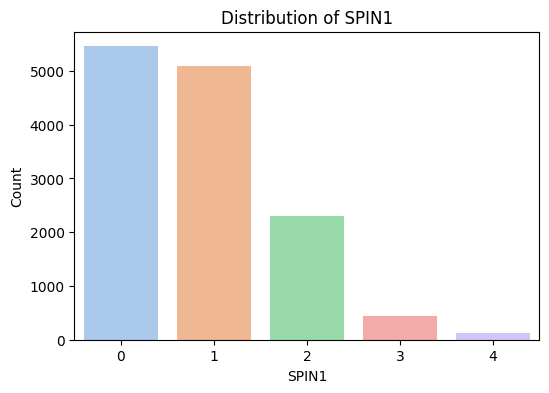

/tmp/ipython-input-4292741977.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=gamers_csv, palette='pastel',


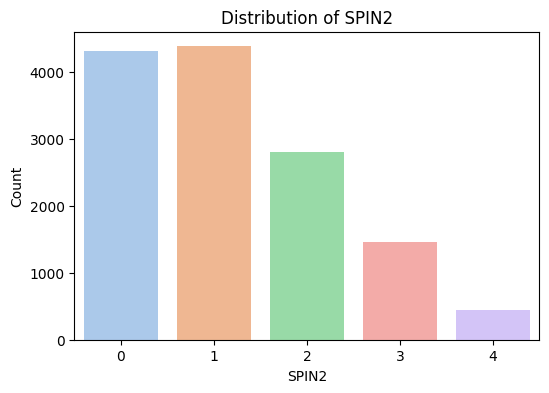

/tmp/ipython-input-4292741977.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=gamers_csv, palette='pastel',


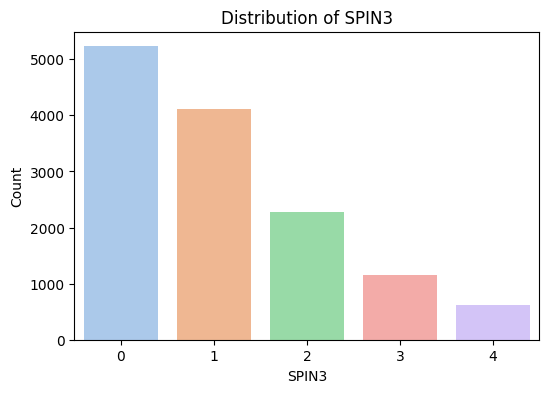

/tmp/ipython-input-4292741977.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=gamers_csv, palette='pastel',


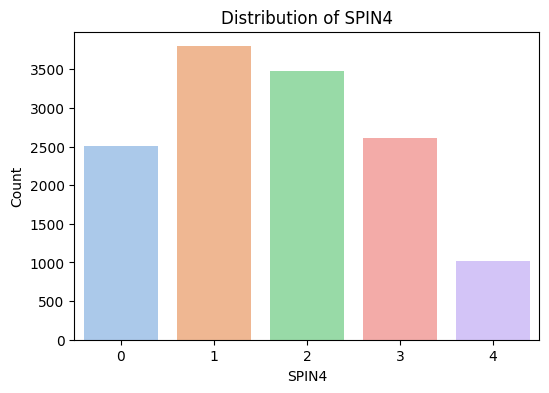

/tmp/ipython-input-4292741977.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=gamers_csv, palette='pastel',


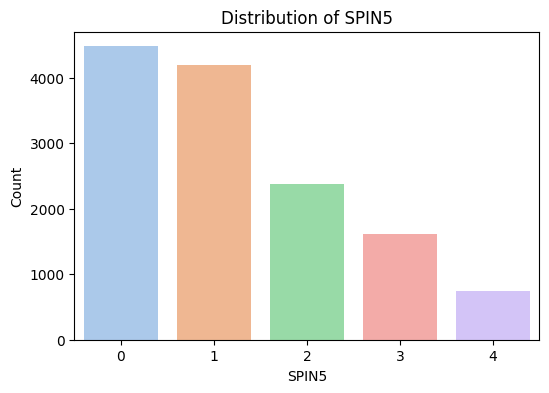

/tmp/ipython-input-4292741977.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=gamers_csv, palette='pastel',


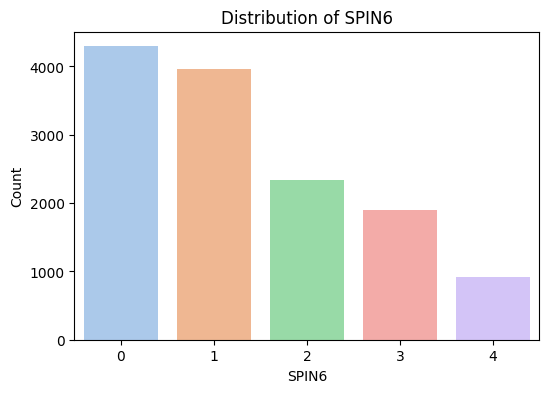

/tmp/ipython-input-4292741977.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=gamers_csv, palette='pastel',


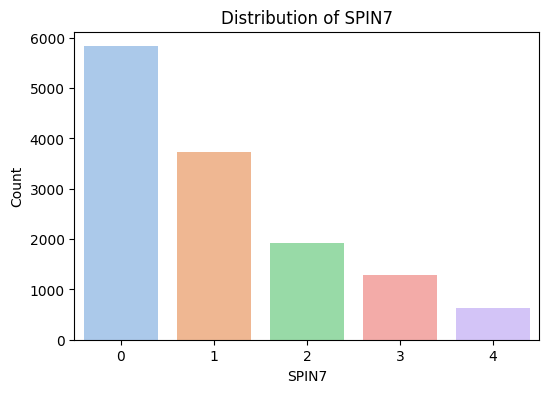

/tmp/ipython-input-4292741977.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=gamers_csv, palette='pastel',


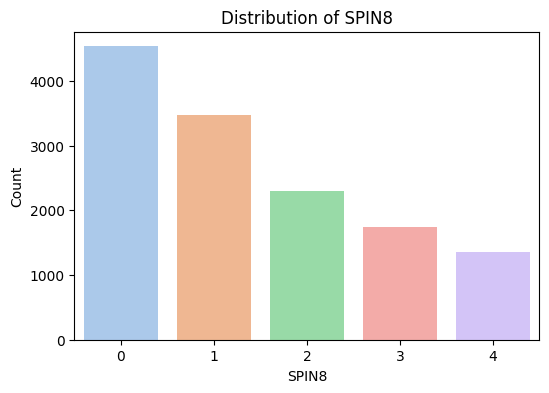

/tmp/ipython-input-4292741977.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=gamers_csv, palette='pastel',


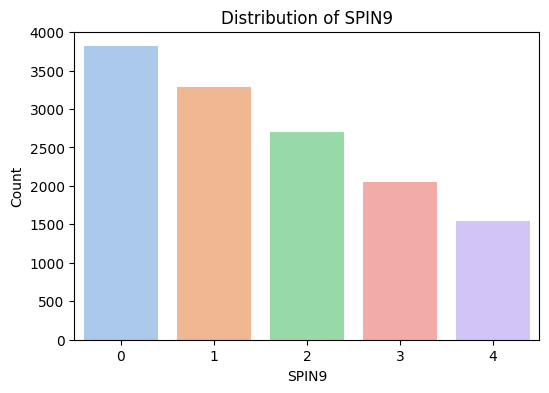

/tmp/ipython-input-4292741977.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=gamers_csv, palette='pastel',


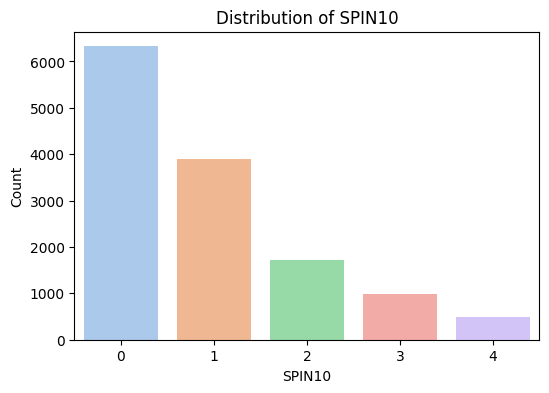

/tmp/ipython-input-4292741977.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=gamers_csv, palette='pastel',


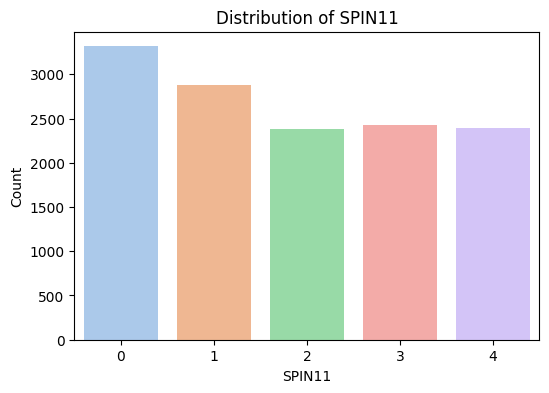

/tmp/ipython-input-4292741977.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=gamers_csv, palette='pastel',


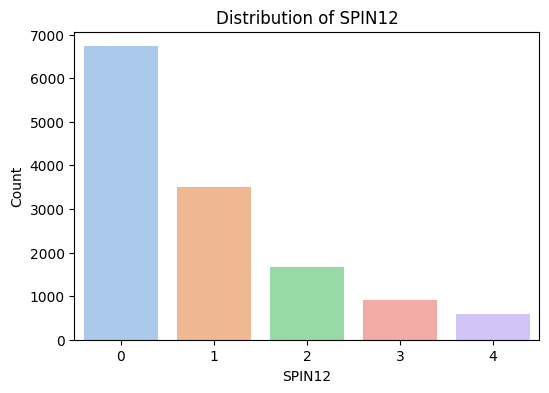

/tmp/ipython-input-4292741977.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=gamers_csv, palette='pastel',


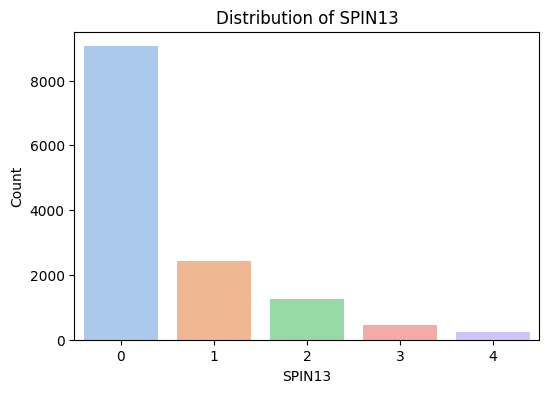

/tmp/ipython-input-4292741977.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=gamers_csv, palette='pastel',


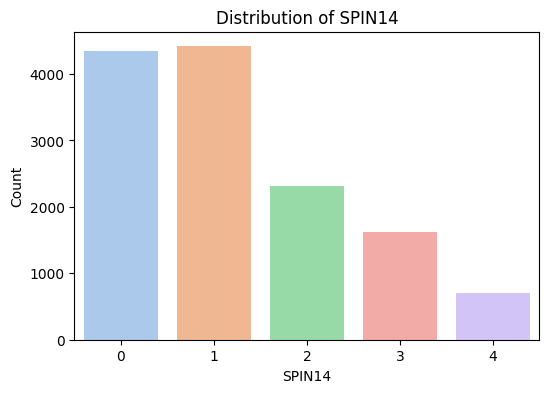

/tmp/ipython-input-4292741977.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=gamers_csv, palette='pastel',


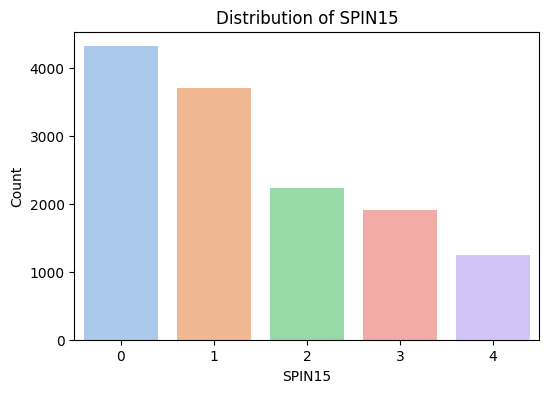

/tmp/ipython-input-4292741977.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=gamers_csv, palette='pastel',


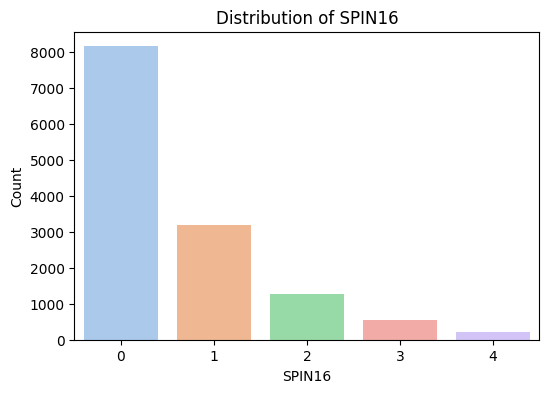

/tmp/ipython-input-4292741977.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=gamers_csv, palette='pastel',


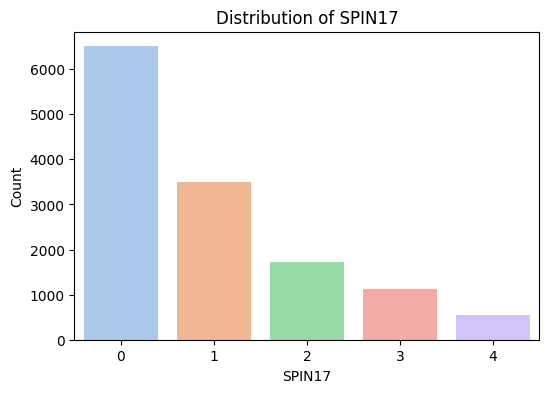

/tmp/ipython-input-4292741977.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=gamers_csv, palette='pastel',


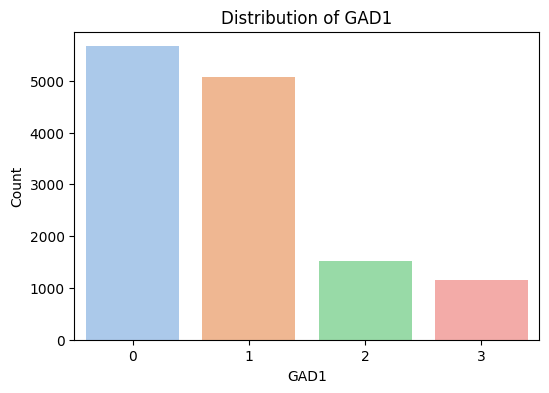

/tmp/ipython-input-4292741977.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=gamers_csv, palette='pastel',


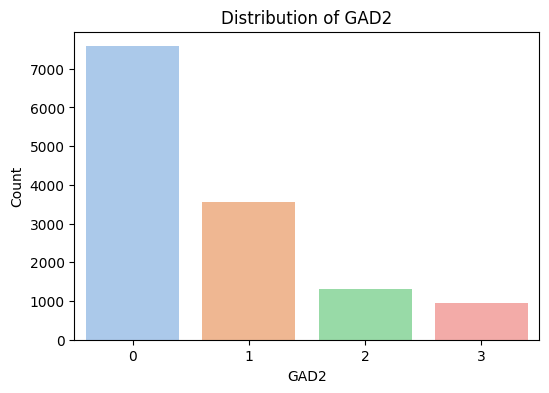

/tmp/ipython-input-4292741977.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=gamers_csv, palette='pastel',


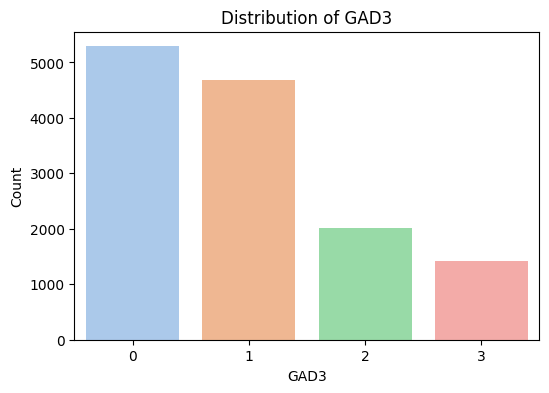

/tmp/ipython-input-4292741977.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=gamers_csv, palette='pastel',


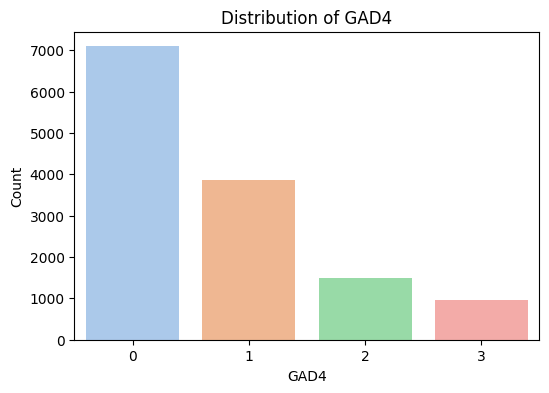

/tmp/ipython-input-4292741977.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=gamers_csv, palette='pastel',


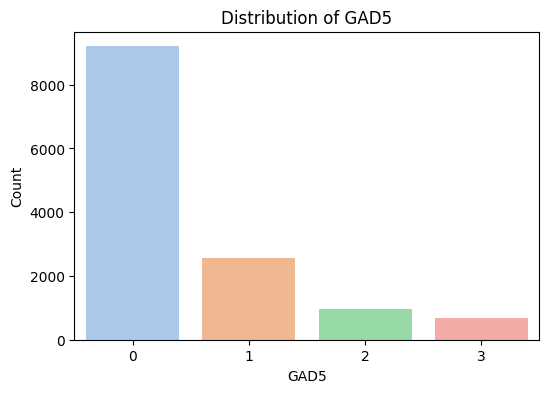

/tmp/ipython-input-4292741977.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=gamers_csv, palette='pastel',


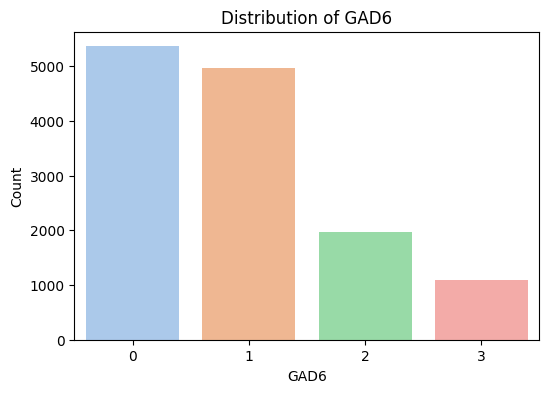

/tmp/ipython-input-4292741977.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=gamers_csv, palette='pastel',


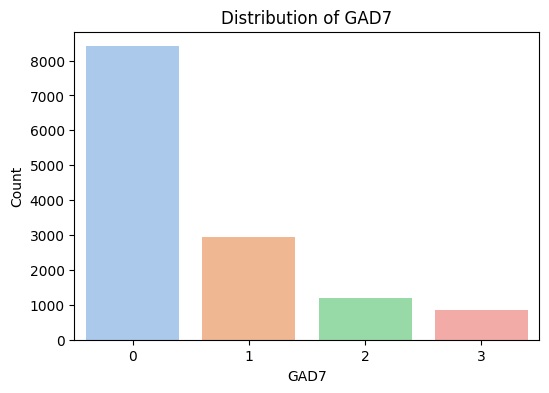

/tmp/ipython-input-4292741977.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=gamers_csv, palette='pastel',


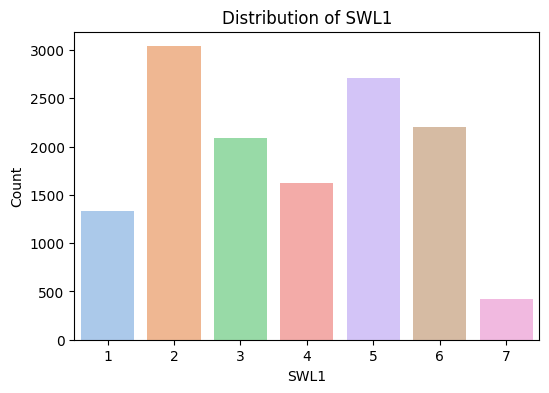

/tmp/ipython-input-4292741977.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=gamers_csv, palette='pastel',


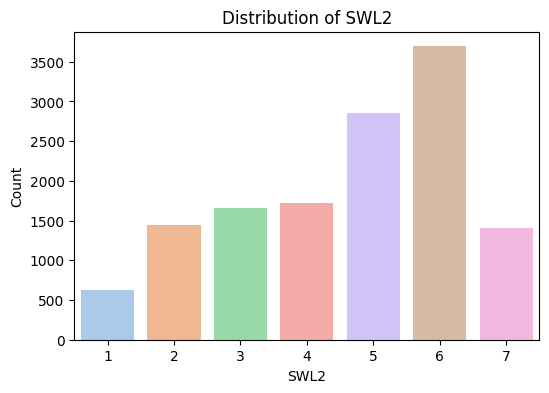

/tmp/ipython-input-4292741977.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=gamers_csv, palette='pastel',


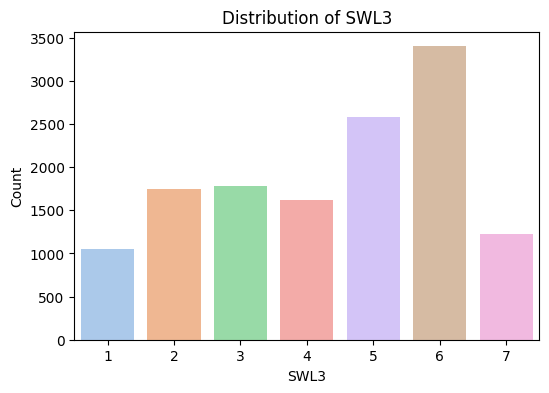

/tmp/ipython-input-4292741977.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=gamers_csv, palette='pastel',


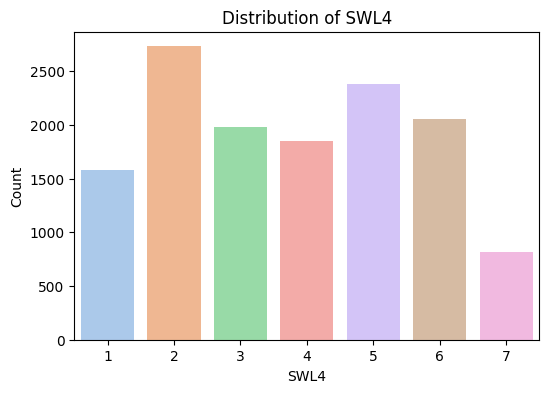

/tmp/ipython-input-4292741977.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=gamers_csv, palette='pastel',


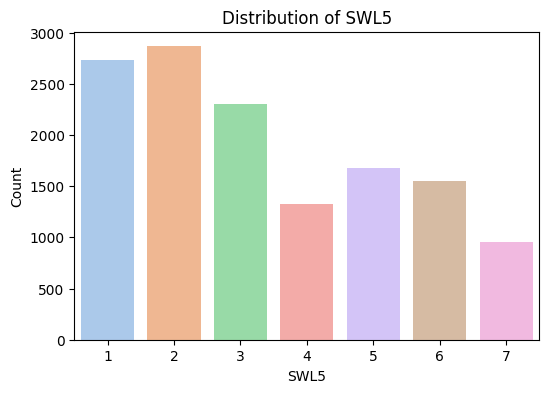

/tmp/ipython-input-4292741977.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=gamers_csv, palette='pastel',


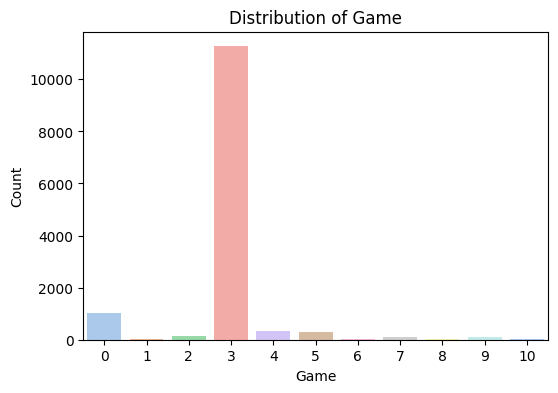

In [ ]:
#---------------RIYA----------------#

# SPIN, GAD, SWL columns
spin_cols = [f"SPIN{i}" for i in range(1, 18)]
gad_cols = [f"GAD{i}" for i in range(1, 8)]
swl_cols = [f"SWL{i}" for i in range(1, 6)]
game_col = ['Game']

survey_cols = spin_cols + gad_cols + swl_cols
all_cols = survey_cols + game_col

# Define ranges for each survey type
survey_ranges = {col: range(0, 5) for col in spin_cols}  # SPIN: 0–4
survey_ranges.update({col: range(0, 4) for col in gad_cols})  # GAD: 0–3
survey_ranges.update({col: range(1, 8) for col in swl_cols})  # SWL: 1–7
survey_ranges.update({'Game': range(0, 11)})  # Game: 0–10


for col in all_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=gamers_csv, palette='pastel',
                  order=survey_ranges[col])  # ensures all possible values appear
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

In [ ]:

# ----------------Nickole--------------------------

# ISO3 conversion for Birthplace / Residence columns
!pip -q install pycountry unidecode

import re, pandas as pd
import pycountry
from unidecode import unidecode

# Load file
PATH = '/content/GamingStudy_cleaned_data_NS (ISO3)-2.xlsx'
df = pd.read_excel(PATH)

# Show columns
print("Columns in file:\n", list(df.columns), "\n")

# Auto-detect the columns to convert
pattern = re.compile(r'(birth\s*place|birthplace|residen[ct]e)\s*.*(country|nation)?', re.I)
candidate_cols = [c for c in df.columns if pattern.search(c)]
print("Detected columns to convert:", candidate_cols, "\n")


# Normalization
SPECIAL = {
    # UK variants
    'uk':'GBR','u.k.':'GBR','great britain':'GBR','britain':'GBR','england':'GBR','scotland':'GBR',
    'wales':'GBR','northern ireland':'GBR','united kingdom':'GBR',
    # USA variants
    'usa':'USA','u.s.a.':'USA','united states':'USA','united states of america':'USA','us':'USA','u.s.':'USA',
    # Korea
    'south korea':'KOR','republic of korea':'KOR','korea, south':'KOR',
    'north korea':'PRK','korea, north':'PRK',
    # Other frequent renames
    'russia':'RUS','czech republic':'CZE','viet nam':'VNM','ivory coast':'CIV','côte d’ivoire':'CIV','cote d ivoire':'CIV',
    'tanzania':'TZA','venezuela':'VEN','laos':'LAO','bolivia':'BOL','moldova':'MDA','iran':'IRN','syria':'SYR',
    'macedonia':'MKD','north macedonia':'MKD','palestine':'PSE','kosovo':'XKX',  # XKX is widely used though not ISO standard
    'eswatini':'SWZ','swaziland':'SWZ','myanmar':'MMR','burma':'MMR','timor-leste':'TLS','east timor':'TLS',
    'hong kong':'HKG','macau':'MAC','cabo verde':'CPV','cape verde':'CPV','brunei':'BRN','curacao':'CUW',
    'saint kitts and nevis':'KNA','st kitts and nevis':'KNA','saint vincent and the grenadines':'VCT',
    'st vincent and the grenadines':'VCT','são tomé and príncipe':'STP','sao tome and principe':'STP'
}

def normalize_name(s):
    s = unidecode(str(s)).strip().lower()

    s = re.sub(r'[\.\,()\[\]{}]+', ' ', s)
    s = re.sub(r'\s+', ' ', s)
    return s

def to_iso3(value):
    if pd.isna(value) or str(value).strip()=='':
        return None
    raw = str(value)
    key = normalize_name(raw)
    # dictionary overrides first
    if key in SPECIAL:
        return SPECIAL[key]
    # pycountry lookup
    try:
        return pycountry.countries.lookup(raw).alpha_3
    except LookupError:
        pass
    # looser search
    for c in pycountry.countries:
        names = {
            c.name,
            getattr(c, 'common_name', ''),
            getattr(c, 'official_name', '')
        }
        if key in {normalize_name(n) for n in names if n}:
            return c.alpha_3
    # last-resort tweaks
    tweaks = [
        ('republic of ', ''), ('people s republic of ', ''), ('democratic republic of ', ''),
        ('federative republic of ', ''), ('federation', ''), ('state of ', ''), ('the ', '')
    ]
    t = key
    for a,b in tweaks:
        t = t.replace(a,b)
    for c in pycountry.countries:
        if normalize_name(c.name) == t:
            return c.alpha_3
    return None  # unresolved; we’ll audit these below

# Convert each detected column → new ISO3 column with suffix _ISO3
unresolved = {}
for col in candidate_cols:
    iso_col = f"{col}_ISO3"
    df[iso_col] = df[col].apply(to_iso3)

    bad = sorted({v for v, iso in zip(df[col], df[iso_col]) if pd.notna(v) and pd.isna(iso)})
    if bad:
        unresolved[col] = bad[:30]  # cap preview

# Quick preview
preview_cols = []
for c in candidate_cols:
    preview_cols += [c, f"{c}_ISO3"]
display(df[preview_cols].head(12))

# Reporting
if unresolved:
    print("\n Unresolved country names (showing up to 30 per column). Add to SPECIAL dict above if needed:")
    for k,v in unresolved.items():
        print(f" - {k}: {v}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 16.3 MB/s eta 0:00:00


FileNotFoundError: [Errno 2] No such file or directory: '/content/GamingStudy_cleaned_data_NS (ISO3)-2.xlsx'

In [ ]:
!pip -q install pycountry unidecode

import re, math, pandas as pd
import pycountry
from unidecode import unidecode

PATH = 'GamingStudy_cleaned_data_NS (ISO3)-2.xlsx'
df = pd.read_excel(PATH)

# Helpers
def _norm_txt(s: str) -> str:
    s = unidecode(str(s)).strip().lower()
    s = re.sub(r'[\.\,()\[\]{}]+', ' ', s)
    s = re.sub(r'\s+', ' ', s)
    return s

# Common aliases
SPECIAL = {
    # UK
    'uk':'GBR','u.k.':'GBR','great britain':'GBR','britain':'GBR','england':'GBR',
    'scotland':'GBR','wales':'GBR','northern ireland':'GBR','united kingdom':'GBR',
    # USA
    'usa':'USA','u.s.a.':'USA','united states':'USA','united states of america':'USA','us':'USA','u.s.':'USA',
    # Korea
    'south korea':'KOR','republic of korea':'KOR','korea, south':'KOR',
    'north korea':'PRK','korea, north':'PRK',
    # Other frequent renames
    'russia':'RUS','czech republic':'CZE','viet nam':'VNM','ivory coast':'CIV','cote d ivoire':'CIV',
    'côte d’ivoire':'CIV','tanzania':'TZA','moldova':'MDA','iran':'IRN','syria':'SYR',
    'myanmar':'MMR','burma':'MMR','laos':'LAO','bolivia':'BOL','venezuela':'VEN',
    'macedonia':'MKD','north macedonia':'MKD','palestine':'PSE',
    'eswatini':'SWZ','swaziland':'SWZ','timor-leste':'TLS','east timor':'TLS',
    'hong kong':'HKG','macau':'MAC','cabo verde':'CPV','cape verde':'CPV',
    # Kosovo (widely used code, not official ISO-3166)
    'kosovo':'XKX'
}

# Pre-build fast maps
ALPHA2_TO_3 = {c.alpha_2: c.alpha_3 for c in pycountry.countries if hasattr(c, 'alpha_2')}
ALPHA3_SET   = {c.alpha_3 for c in pycountry.countries}
NUM_TO_3     = {int(c.numeric): c.alpha_3 for c in pycountry.countries if hasattr(c, 'numeric')}

def to_iso3(value):
    """Return ISO-3166 alpha-3 code or None from name/alpha2/alpha3/numeric (int/str/float)."""
    if value is None or (isinstance(value, float) and math.isnan(value)):
        return None

    s = str(value).strip()
    if s == '':
        return None

    # Numeric paths (handles 840, '840', 840.0)
    try:
        n = int(float(s))
        if n in NUM_TO_3:
            return NUM_TO_3[n]
    except ValueError:
        pass

    # Already alpha-3?
    if len(s) == 3 and s.isalpha():
        up = s.upper()
        if up in ALPHA3_SET:
            return up

    # Alpha-2?
    if len(s) == 2 and s.isalpha():
        up2 = s.upper()
        if up2 in ALPHA2_TO_3:
            return ALPHA2_TO_3[up2]

    # Dictionary overrides (normalized names)
    key = _norm_txt(s)
    if key in SPECIAL:
        return SPECIAL[key]

    # pycountry lookup on raw string
    try:
        return pycountry.countries.lookup(s).alpha_3
    except LookupError:
        pass

    # Try official/common names
    for c in pycountry.countries:
        cand = {_norm_txt(c.name)}
        if hasattr(c, 'official_name'): cand.add(_norm_txt(c.official_name))
        if hasattr(c, 'common_name'):  cand.add(_norm_txt(c.common_name))
        if key in cand:
            return c.alpha_3

    return None

# Pick up any Birthplace/Residence columns (tolerant to typos like IS03 vs ISO3)
birth_cols = [c for c in df.columns if re.search(r'birth\s*place|birthplace', c, re.I)]
res_cols   = [c for c in df.columns if re.search(r'residen[ct]e', c, re.I)]

print("Birthplace columns found:", birth_cols)
print("Residence columns found:", res_cols)

# Convert each to a companion *_alpha3 column
for c in birth_cols + res_cols:
    df[c + '_alpha3'] = df[c].apply(to_iso3)

# Coalesce to single clean fields
def coalesce_alpha3(cols):
    out = None
    for c in cols:
        cand = df[c + '_alpha3']
        out = cand if out is None else out.fillna(cand)
    return out

df['Birthplace_alpha3'] = coalesce_alpha3([c for c in birth_cols])
df['Residence_alpha3']  = coalesce_alpha3([c for c in res_cols])

# Quick QA
preview = (birth_cols + [c + '_alpha3' for c in birth_cols] +
           res_cols  + [c + '_alpha3' for c in res_cols] +
           ['Birthplace_alpha3','Residence_alpha3'])
display(df[preview].head(12))

# Any unresolved?
unresolved_birth = df.loc[df['Birthplace_alpha3'].isna(), birth_cols].head(25)
unresolved_res   = df.loc[df['Residence_alpha3'].isna(),  res_cols].head(25)
print("\nUnresolved Birthplace examples:\n", unresolved_birth)
print("\nUnresolved Residence examples:\n", unresolved_res)

# Save a clean file for the team
df.to_csv('GamingStudy_with_alpha3.csv', index=False)
print("\nSaved → GamingStudy_with_alpha3.csv")

In [ ]:
#--------------------MANASA--------------------------#
# text classification of Earnings column using Topic modeling unsupervised learning

EARN_COL = "earnings"

N_TOPICS = 8          # top-level NMF topics
N_MICRO = 6           # micro-topics for primary cluster 0
RANDOM_STATE = 42

current_date = datetime.now().strftime("%Y-%m-%d")
OUTPUT_PATH = f"{current_date}_gamers_cleaned_with_earnings_topics.csv"

# Helper function
def clean_text(s: str) -> str:
    """Basic normalization for short noisy survey text."""
    s = str(s).lower()
    s = re.sub(r"http\S+|www\.\S+", " ", s)        # remove links
    s = re.sub(r"[^a-z\s']", " ", s)              # keep letters/spaces/' only
    s = re.sub(r"\s+", " ", s).strip()            # collapse whitespace
    return s

# Load + clean

earn_raw = gamers_csv[EARN_COL].fillna("").astype(str).str.strip()
earn_clean = earn_raw.apply(clean_text)

# Making a TF-IDF vectorizer for converting text data into numerical scores of word occurences
# First-level NMF (Non-negative Matrix Factorization) Topic Modeling
# with 8 pre-assigned clusters
tfidf = TfidfVectorizer(
    stop_words="english",
    min_df=3,
    max_df=0.9,
    ngram_range=(1, 2)
)
X = tfidf.fit_transform(earn_clean)

# Assign clusters
nmf = NMF(
    n_components=N_TOPICS,
    random_state=RANDOM_STATE,
    init="nndsvda",
    max_iter=500
)
W = nmf.fit_transform(X)
primary_clusters = W.argmax(axis=1)   # 0..N_TOPICS-1

# Cluster 0 has maximum entries. This needs to be sub-clustered further
# Identify cluster 0 rows

cluster0_idx = np.where(primary_clusters == 0)[0]

# Default subcluster = NaN for non-cluster0 rows
micro_clusters = np.full(len(df), np.nan)

if len(cluster0_idx) > 0:
    earn_c0 = earn_clean.iloc[cluster0_idx]

    tfidf_c0 = TfidfVectorizer(
        stop_words="english",
        min_df=1,          # allow rare words so micro-structure can emerge
        max_df=0.9,
        ngram_range=(1, 2)
    )
    Xc0 = tfidf_c0.fit_transform(earn_c0)

    nmf_c0 = NMF(
        n_components=N_MICRO,
        random_state=RANDOM_STATE,
        init="nndsvda",
        max_iter=500
    )
    Wc0 = nmf_c0.fit_transform(Xc0)
    micro_ids = Wc0.argmax(axis=1)  # 0..N_MICRO-1 within cluster 0

    # write micro IDs back into full-length array
    micro_clusters[cluster0_idx] = micro_ids

# -----------------------------
# Insert new columns next to earnings
# -----------------------------
earn_pos = gamers_csv.columns.get_loc(EARN_COL)

gamers_csv.insert(earn_pos + 1, "earnings_cluster", primary_clusters)
gamers_csv.insert(earn_pos + 2, "earnings_subcluster", micro_clusters)

# -----------------------------
# Save
# -----------------------------
gamers_csv.to_csv(OUTPUT_PATH, index=False)
print("Saved:", OUTPUT_PATH)
print(gamers_csv[[EARN_COL, "earnings_cluster", "earnings_subcluster"]].head(10))


In [55]:
#--------------------Ming--------------------------#
# Reading the encoding from the source file to help with UTF decoding errors observed during type coercion and encoding
#from google.colab import drive
#drive.mount('/content/drive')
fileName = '/content/drive/My Drive/Colab Notebooks/GamingStudy_cleaned_data_replace_columns_with_enums.csv'

gamers_csv = pd.read_csv(fileName, encoding=file_encoding, engine='python')
gamers_csv_original = gamers_csv.copy()
pd.set_option('display.max_columns', None)
gamers_csv

,S. No.,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GADE,SWL1,SWL2,SWL3,SWL4,SWL5,Game,Platform,Hours,earnings,whyplay,League,streams,SPIN1,SPIN2,SPIN3,SPIN4,SPIN5,SPIN6,SPIN7,SPIN8,SPIN9,SPIN10,SPIN11,SPIN12,SPIN13,SPIN14,SPIN15,SPIN16,SPIN17,Narcissism,Gender,Age,Work,Degree,Playstyle,GAD_T,SWL_T,SPIN_T,Residence_ISO3,Birthplace_ISO3
0,1,0,0,0,0,1,0,0,Not difficult at all,3,5,5,5,5,1,2,15,I play for fun,having fun,NaN,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1,Male,25,Unemployed / between jobs,Bachelor (or equivalent),1,1,23,5.0,USA,USA
1,2,1,2,2,2,0,1,0,Somewhat difficult,3,5,2,5,1,0,1,8,I play for fun,having fun,NaN,2.0,2.0,1.0,1.0,3.0,2.0,3.0,1.0,3.0,4.0,0.0,3.0,0.0,1.0,3.0,3.0,1.0,2.0,1,Male,41,Unemployed / between jobs,Bachelor (or equivalent),3,8,16,33.0,USA,USA
2,3,0,2,2,0,0,3,1,Not difficult at all,2,6,5,2,2,0,1,1,I play for fun,having fun,NaN,0.0,1.0,0.0,1.0,2.0,3.0,4.0,2.0,1.0,0.0,1.0,1.0,3.0,0.0,2.0,4.0,4.0,2.0,4,Female,32,Employed,Bachelor (or equivalent),1,8,17,31.0,DEU,DEU
3,4,0,0,0,0,0,0,0,Not difficult at all,2,5,5,3,2,0,1,20,I play for fun,improving,NaN,5.0,2.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,1.0,0.0,0.0,2,Male,28,Employed,Bachelor (or equivalent),4,0,17,11.0,USA,USA
4,5,2,1,2,2,2,3,2,Very difficult,2,2,4,5,1,0,2,20,I play for fun,having fun,NaN,1.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,4.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,3.0,0.0,1,Male,19,Employed,High school diploma (or equivalent),3,14,14,13.0,KOR,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13401,14246,1,0,0,1,0,1,1,Not difficult at all,6,6,5,5,6,0,2,40,I play for fun,improving,NaN,10.0,1.0,1.0,1.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3,Male,22,Student at college / university,Master (or equivalent),3,4,28,7.0,FRA,FRA
13402,14247,3,3,3,3,2,3,3,Extremely difficult,5,5,5,4,4,3,1,20,I play for fun,winning,NaN,20.0,0.0,1.0,2.0,2.0,0.0,1.0,3.0,3.0,2.0,1.0,4.0,0.0,2.0,2.0,1.0,0.0,1.0,2,Female,20,Student at college / university,High school diploma (or equivalent),3,20,23,25.0,USA,USA
13403,14248,0,0,0,0,0,0,0,Not difficult at all,6,6,7,7,6,4,1,20,I play for fun,having fun,Gold,14.0,0.0,1.0,0.0,2.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,2,Male,19,Student at college / university,High school diploma (or equivalent),5,0,32,10.0,NOR,NOR
13404,14249,3,2,1,3,0,1,3,Somewhat difficult,2,6,3,2,3,0,2,5,I play for fun,having fun,NaN,0.0,0.0,1.0,3.0,2.0,3.0,4.0,1.0,3.0,4.0,1.0,3.0,1.0,0.0,3.0,2.0,0.0,1.0,2,Female,18,Student at school,High school diploma (or equivalent),1,13,16,32.0,CAN,CAN


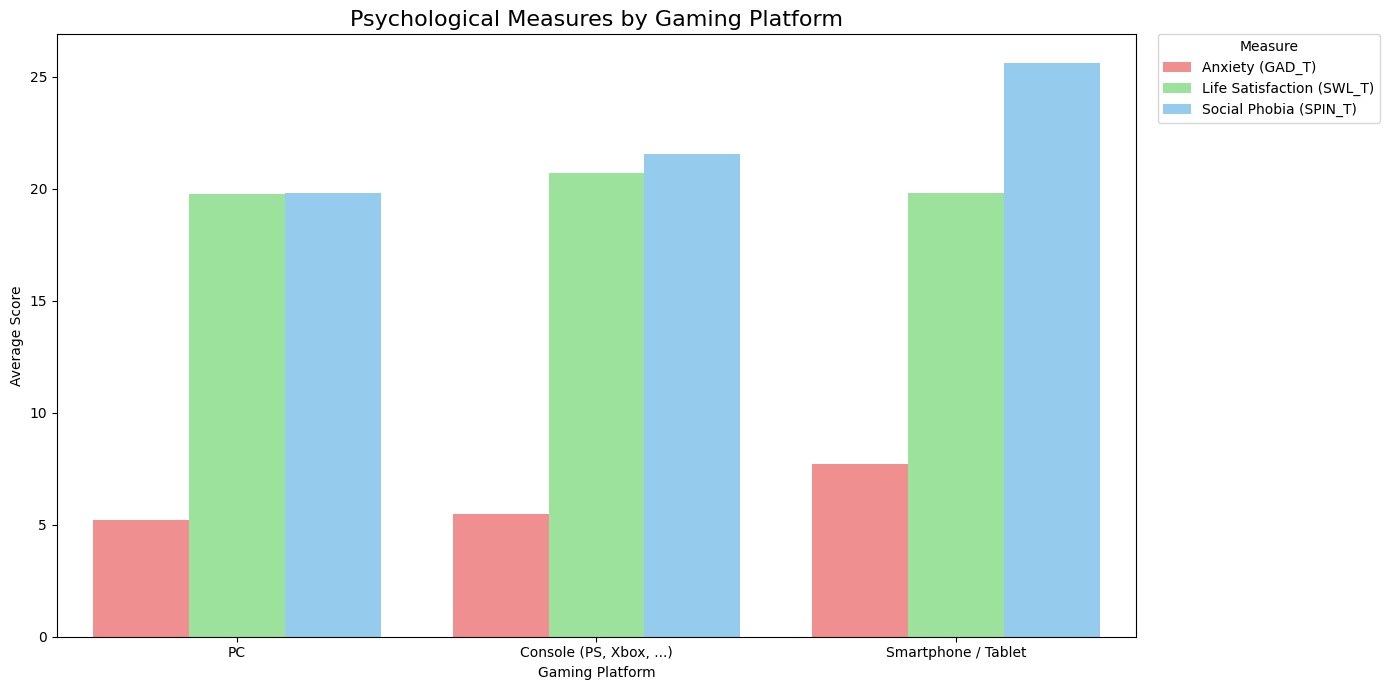

In [56]:
platform_data = gamers_csv.groupby('Platform')[['GAD_T', 'SWL_T', 'SPIN_T']].mean().reset_index()

# Define the mapping from numerical platform codes to descriptive labels
# Based on the user's input and observed values in the 'Platform' column (0, 1, 2)
platform_label_map = {
    1: "PC",
    2: "Console (PS, Xbox, ...)",
    3: "Smartphone / Tablet"
}

# Apply the mapping to create a new column with descriptive labels
platform_data['Platform_Label'] = platform_data['Platform'].map(platform_label_map)

platform_melted = pd.melt(
    platform_data,
    id_vars=['Platform', 'Platform_Label'], # Include 'Platform_Label' in id_vars
    value_vars=['GAD_T', 'SWL_T', 'SPIN_T'],
    var_name='Measure',
    value_name='Score'
)

color_map = {
    'GAD_T': '#FF7F7F',
    'SWL_T': '#90EE90',
    'SPIN_T': '#87CEFA'
}

plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=platform_melted,
    x='Platform_Label', # Use the new 'Platform_Label' column for the x-axis
    y='Score',
    hue='Measure',
    palette=color_map
)

plt.title('Psychological Measures by Gaming Platform', fontsize=16)
plt.xlabel('Gaming Platform')
plt.ylabel('Average Score')

handles, labels = ax.get_legend_handles_labels()
plt.legend(
    handles,
    ['Anxiety (GAD_T)', 'Life Satisfaction (SWL_T)', 'Social Phobia (SPIN_T)'],
    title='Measure',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0
)

plt.tight_layout()
plt.savefig('platform_analysis_clean.png', dpi=300, bbox_inches='tight')
plt.show()

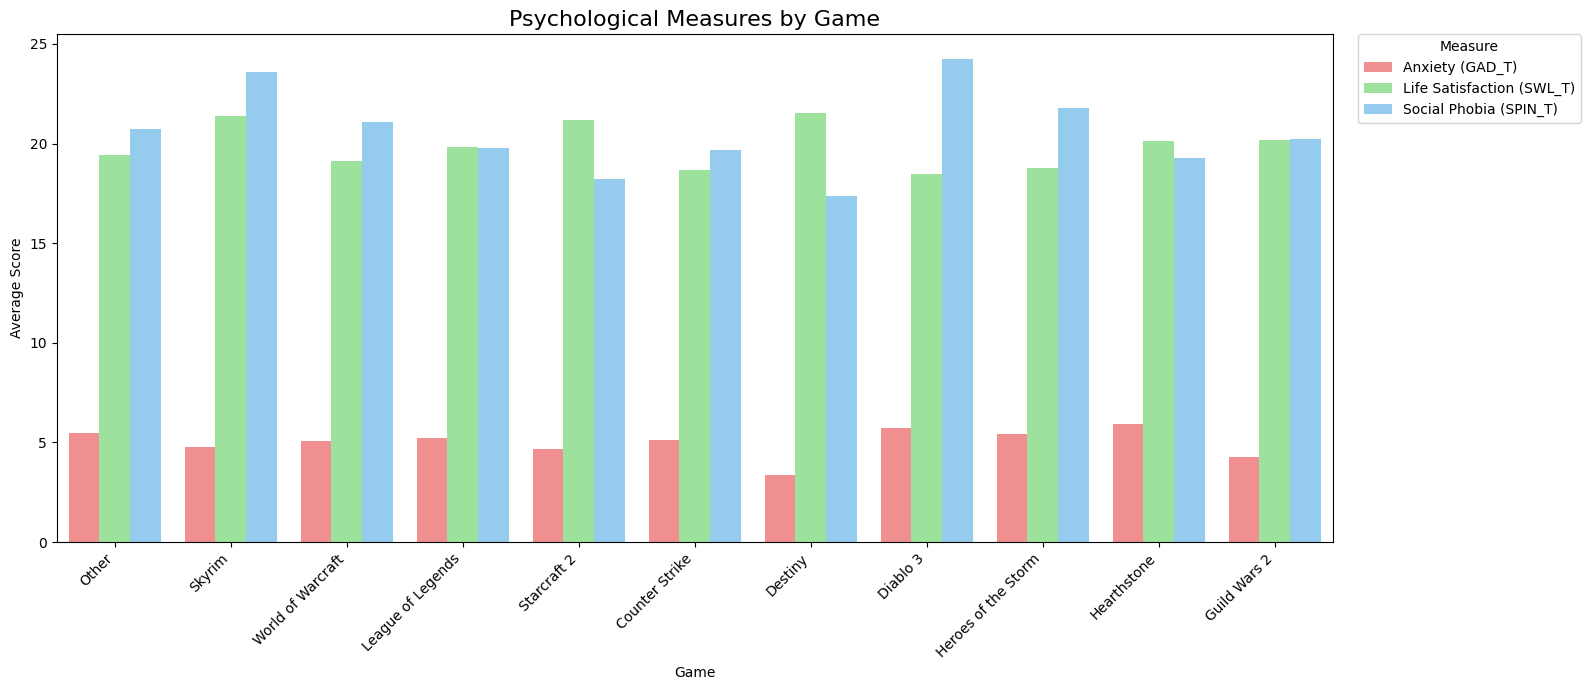

In [57]:
game_data = gamers_csv.groupby('Game')[['GAD_T', 'SWL_T', 'SPIN_T']].mean().reset_index()

# Define game code mapping - re-using the one from cell uTvA-L0M3peh
game_code_mapping = {
    0: "Other",
    1: "Skyrim",
    2: "World of Warcraft",
    3: "League of Legends",
    4: "Starcraft 2",
    5: "Counter Strike",
    6: "Destiny",
    7: "Diablo 3",
    8: "Heroes of the Storm",
    9: "Hearthstone",
    10: "Guild Wars 2"
}

# Apply the mapping to create a new column with descriptive labels
game_data['Game_Label'] = game_data['Game'].map(game_code_mapping).fillna("Unknown")

game_melted = pd.melt(
    game_data,
    id_vars=['Game', 'Game_Label'], # Include 'Game_Label' in id_vars
    value_vars=['GAD_T', 'SWL_T', 'SPIN_T'],
    var_name='Measure',
    value_name='Score'
)

color_map = {
    'GAD_T': '#FF7F7F',
    'SWL_T': '#90EE90',
    'SPIN_T': '#87CEFA'
}

plt.figure(figsize=(16, 7))
ax = sns.barplot(
    data=game_melted,
    x='Game_Label', # Use the new 'Game_Label' column for the x-axis
    y='Score',
    hue='Measure',
    palette=color_map
)

plt.title('Psychological Measures by Game', fontsize=16)
plt.xlabel('Game')
plt.ylabel('Average Score')

plt.xticks(rotation=45, ha='right')

handles, labels = ax.get_legend_handles_labels()
plt.legend(
    handles,
    ['Anxiety (GAD_T)', 'Life Satisfaction (SWL_T)', 'Social Phobia (SPIN_T)'],
    title='Measure',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0
)

plt.tight_layout()
plt.savefig('game_analysis_clean.png', dpi=300, bbox_inches='tight')
plt.show()

The output of the previous cell shows the count for each game code present in your `gamers_csv` DataFrame. If a game code from your `game_code_mapping` is not listed or has a count of 0, it means there are no players associated with that game in your dataset, and thus it won't appear in the graph. This explains why some games from your mapping are missing from the visualization.

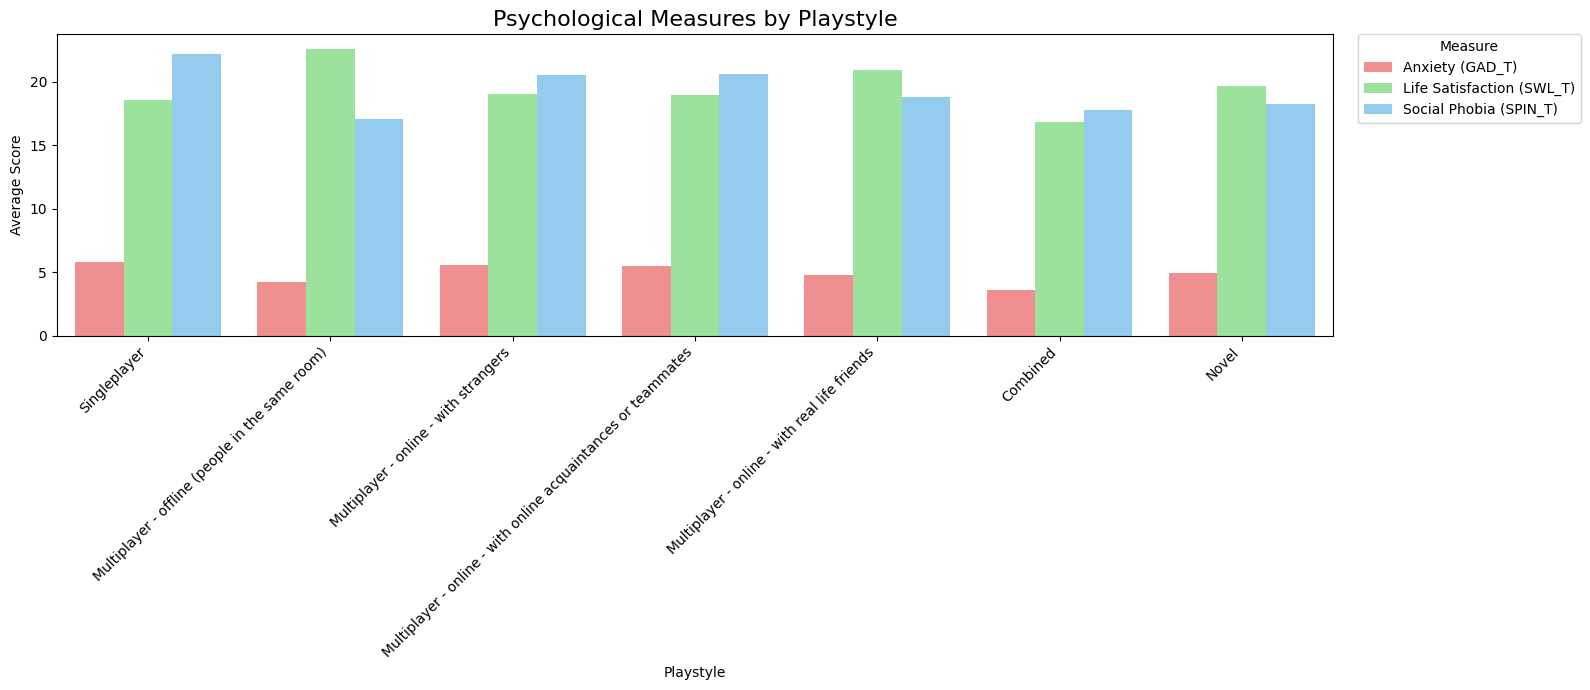

In [58]:
playstyle_data = gamers_csv.groupby('Playstyle')[['GAD_T', 'SWL_T', 'SPIN_T']].mean().reset_index()

# Define playstyle code mapping
playstyle_mapping = {
    1: "Singleplayer",
    2: "Multiplayer - offline (people in the same room)",
    3: "Multiplayer - online - with strangers",
    4: "Multiplayer - online - with online acquaintances or teammates",
    5: "Multiplayer - online - with real life friends",
    6: "Combined",
    7: "Novel"
}

# Apply the mapping to create a new column with descriptive labels
# Handle case where 'Playstyle' might contain values not in mapping (e.g., 0 from GADE in cell HXgJtjXybCyE)
playstyle_data['Playstyle_Label'] = playstyle_data['Playstyle'].map(playstyle_mapping).fillna("Unknown")

playstyle_melted = pd.melt(
    playstyle_data,
    id_vars=['Playstyle', 'Playstyle_Label'], # Include 'Playstyle_Label' in id_vars
    value_vars=['GAD_T', 'SWL_T', 'SPIN_T'],
    var_name='Measure',
    value_name='Score'
)

color_map = {
    'GAD_T': '#FF7F7F',
    'SWL_T': '#90EE90',
    'SPIN_T': '#87CEFA'
}

plt.figure(figsize=(16, 7))
ax = sns.barplot(
    data=playstyle_melted,
    x='Playstyle_Label', # Use the new 'Playstyle_Label' column for the x-axis
    y='Score',
    hue='Measure',
    palette=color_map
)

plt.title('Psychological Measures by Playstyle', fontsize=16)
plt.xlabel('Playstyle')
plt.ylabel('Average Score')

plt.xticks(rotation=45, ha='right')

handles, labels = ax.get_legend_handles_labels()
plt.legend(
    handles,
    ['Anxiety (GAD_T)', 'Life Satisfaction (SWL_T)', 'Social Phobia (SPIN_T)'],
    title='Measure',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0
)

plt.tight_layout()
plt.savefig('playstyle_analysis_clean.png', dpi=300, bbox_inches='tight')
plt.show()

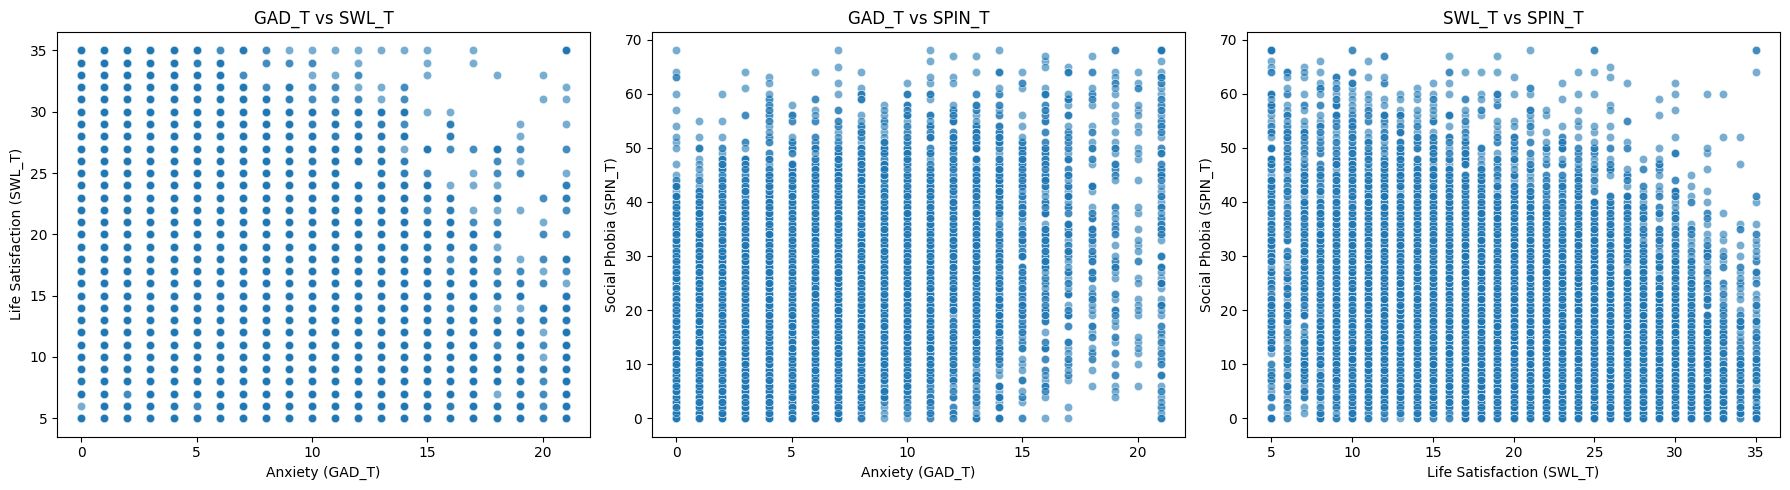

In [64]:
# This cell generates scatter plots to visualize the relationships between the three psychological measures: GAD_T, SWL_T, and SPIN_T.
import matplotlib.pyplot as plt
import seaborn as sns

psych_measures = ['GAD_T', 'SWL_T', 'SPIN_T']

# Create scatter plots for each pair of psychological measures
plt.figure(figsize=(18, 5))

# GAD_T vs SWL_T
plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
sns.scatterplot(x='GAD_T', y='SWL_T', data=gamers_csv, alpha=0.6)
plt.title('GAD_T vs SWL_T')
plt.xlabel('Anxiety (GAD_T)')
plt.ylabel('Life Satisfaction (SWL_T)')

# GAD_T vs SPIN_T
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
sns.scatterplot(x='GAD_T', y='SPIN_T', data=gamers_csv, alpha=0.6)
plt.title('GAD_T vs SPIN_T')
plt.xlabel('Anxiety (GAD_T)')
plt.ylabel('Social Phobia (SPIN_T)')

# SWL_T vs SPIN_T
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
sns.scatterplot(x='SWL_T', y='SPIN_T', data=gamers_csv, alpha=0.6)
plt.title('SWL_T vs SPIN_T')
plt.xlabel('Life Satisfaction (SWL_T)')
plt.ylabel('Social Phobia (SPIN_T)')

plt.tight_layout()
plt.show()